# Research on Russian Film Distribution

In this project, I will try to study the Russian film distribution market and identify current trends. I will focus on films that have received state support and attempt to answer the question of how interesting these films are to the audience.

The data I will work with is published on the open data portal of the Ministry of Culture. The dataset contains information on film distribution certificates, box office revenues, and state support for films, as well as data from the KinoPoisk website.

# Research Plan
1. Data Inspection
2. Data Preprocessing
3. Exploratory Data Analysis
4. Study of Films with State Support
5. Overall Conclusion

# Research Goals

Identify current trends in the Russian film distribution market, study films that have received state support, and determine how interesting they are to the audience.

# Data description

The `mkrf_movies` table contains information from the registry of film distribution certificates. One film may have several distribution certificates.

- `title` — film title;
- `puNumber` — distribution certificate number;
- `show_start_date` — film premiere date;
- `type` — type of film;
- `film_studio` — producing studio;
- `production_country` — country of production;
- `director` — director;
- `producer` — producer;
- `age_restriction` — age rating;
- `refundable_support` — amount of refundable state support funds;
- `nonrefundable_support` — amount of non-refundable state support funds;
- `financing_source` — source of state financing;
- `budget` — total film budget;
- `ratings` — film rating on KinoPoisk;
- `genres` — film genre.

The `mkrf_shows` table contains information on film screenings in Russian cinemas.

- `puNumber` — distribution certificate number;
- `box_office` — box office revenue in rubles.

## Data Inspection

First, let's import the necessary libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Let's load the data from both datasets and set the output for floating-point numbers.

In [2]:
mkrf_shows = pd.read_csv("./mkrf_shows.csv")
mkrf_movies = pd.read_csv("./mkrf_movies.csv")

pd.options.display.float_format = '{:.2f}'.format

Now let's check if everything was read correctly.

In [3]:
mkrf_shows.head(10)

,puNumber,box_office
0,111000113,2450.00
1,111000115,61040.00
2,111000116,153030013.40
3,111000117,12260956.00
4,111000118,163684057.79
5,111000119,4293649.51
6,111000212,200.00
7,111000216,355567.00
8,111000313,710.00
9,111000314,1607970.00


In [4]:
mkrf_movies.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия"
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия"
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал"
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия"


All data was read correctly, let's continue working.

Let's take a look at the general information about the data; it might give us clues on how to combine them.

In [5]:
mkrf_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [6]:
mkrf_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

It’s clear that the `puNumber` column exists in both datasets, which we'll use for merging. However, there's an issue: the data types in these columns differ. We'll convert them to the same type using the `to_numeric` method and turn any invalid values into `NaN` with the `errors` parameter.

In [7]:
mkrf_movies['puNumber'] = pd.to_numeric(mkrf_movies['puNumber'], errors='coerce').astype('Int64')

After converting the data type, we'll remove all `NaN` values.

In [8]:
mkrf_movies = mkrf_movies.dropna(subset=['puNumber'])

To merge, I use pandas' `merge` method. Since I want to ensure all entries from the `mkrf_movies` dataset are included in the resulting dataframe, I set the `how` parameter to `'left'`.

In [9]:
data = pd.merge(mkrf_movies, mkrf_shows, on='puNumber', how="left")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   Int64  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

The merge was successful, and all data has been included.

## Data Preprocessing

### Checking data types

Let's look at the other data types in the dataset and convert them where necessary.

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   Int64  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

In [11]:
data.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


Based on these data, you can convert the following columns:
- `title` can be converted to `string`
- `type` can be converted to `string`
- `production country` can be converted to `string`
- `director` can be converted to `string`
- `ratings` can be converted to `float`

In [12]:
data['title'] = data['title'].astype('string')
data['type'] = data['type'].astype('string')
data['production_country'] = data['production_country'].astype('string')
data['director'] = data['director'].astype('string')
data['genres'] = data['genres'].astype('string')

### Studying missing values in the dataframe

In [13]:
data['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

Converting from `object` type to `float` likely won't go as smoothly as desired due to the `%` sign. I'll use the `apply` method to apply a custom function to handle these values.

In [14]:
def convert_rating(value):
    if isinstance(value, str) and value.endswith('%'): 
        return float(value.rstrip('%')) / 100
    return value

data['ratings'] = data['ratings'].apply(convert_rating)
data['ratings'] = data['ratings'].astype('float')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   string 
 1   puNumber               7485 non-null   Int64  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   string 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   string 
 6   director               7476 non-null   string 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   float64
 14  genres                 6510 non-null   string 
 15  box_

Great, now all the types are correct.

### Examining duplicates in the dataframe.

In [15]:
print(data.duplicated().any()) 

False


As you can see, there are no duplicates in the data.

### Examining categorical values.

In [16]:
data['type'].unique()

<StringArray>
[            'Художественный',               'Анимационный',
                     'Прочие',             'Документальный',
          'Научно-популярный',            ' Художественный',
              ' Анимационный', 'Музыкально-развлекательный']
Length: 8, dtype: string

It can be observed that the `type` column contains implicit duplicates due to an extra space.

In [17]:
data['type'] = data['type'].str.strip()
data['type'].unique()

<StringArray>
[            'Художественный',               'Анимационный',
                     'Прочие',             'Документальный',
          'Научно-популярный', 'Музыкально-развлекательный']
Length: 6, dtype: string

A similar pattern can be observed in other categorical data.

In [18]:
data['film_studio'].unique()

array(['Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз',
       'Киностудия "Мосфильм"',
       'Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз',
       ...,
       'Дэниел Гродник Продакшнз, Вандерфилм Медиа Корпорэйшн, Импринт Интертейнмент, Вор Хорс Интертейнмент, Пимиента ',
       'Никелодеон Анимейшн Студиос, Спин Мастер',
       'Анимаккорд Лтд., ООО Студия "АНИМАККОРД"'], dtype=object)

In [19]:
data['production_country'].unique()

<StringArray>
[                                                                'США',
                                                                'СССР',
                                                             'Франция',
                                                       'СССР, Венгрия',
                                             'Германия-Великобритания',
                                             'Великобритания - Италия',
                                                        'Чехословакия',
                                              'США - Франция - Турция',
                                                      'Новая Зеландия',
                                          'Канада - Франция - Испания',
 ...
                                        'Франция, Бельгия, Люксембург',
                                                   'Финляндия, Латвия',
                                                            'Пакистан',
                                             

Let's remove extra spaces from all categorical data.

In [20]:
data['film_studio'] = data['film_studio'].str.strip()
data['director'] = data['director'].str.strip()
data['producer'] = data['producer'].str.strip()
data['age_restriction'] = data['age_restriction'].str.strip()
data['film_studio'] = data['film_studio'].str.strip()
data['financing_source'] = data['financing_source'].str.strip()
data['genres'] = data['genres'].str.strip()

Now everything is great.

### Check quantitative values

Let's see if any suspicious data is detected and analyze them.

Looking at the dataset, it's clear that the budget column is the sum of returned financial aid and non-returned financial aid. For data cleaning, we can apply a function to recalculate all missing values where possible. That is, if we know the total budget and the returned financial aid, we can compute the third column.

In [21]:
def budget_cleaning(row):
    if sum(pd.notna([row['budget'], row['refundable_support'], row['nonrefundable_support']])) >= 2:
        if pd.isna(row['budget']):
            row['budget'] = row['refundable_support'] + row['nonrefundable_support']
        elif pd.isna(row['refundable_support']):
            row['refundable_support'] = row['budget'] - row['nonrefundable_support']
        elif pd.isna(row['nonrefundable_support']):
            row['nonrefundable_support'] = row['budget'] - row['refundable_support']
    return row

data = data.apply(budget_cleaning, axis=1)

### Adding new columns

Let's create a separate column for the release year.

In [22]:
data['year'] = data['show_start_date'].apply(lambda x: x[:4])
data.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.20,"боевик,драма,мелодрама",NaN,2015
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.60,"драма,военный",NaN,2016
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2015


Let's create two columns: one with the first and last name of the main director, and another with the main genre of the movie. Each column will take the first value from the respective lists of directors and genres.

To create these columns, I'll use a custom function that can be applied to both columns simultaneously.

In [23]:
data['main_genre'] = data['genres'].apply(lambda x: x.split(',')[0] if pd.notna(x) else None)

Let's calculate what share of the total movie budget is represented by government support.

In [24]:
def ref_sprt_percentage(row):
    refundable_support = row['refundable_support']
    budget = row['budget']
    
    if not pd.isna(refundable_support) and not pd.isna(budget) and budget != 0:
        row['refundable_support_portion'] = refundable_support / budget
    else:
        row['refundable_support_portion'] = pd.NA 
    
    return row

data = data.apply(ref_sprt_percentage, axis=1)

## Exploratory Data Analysis


Let's count the total number of films with known box office data.

In [25]:
movies_with_box_office = (
        data.dropna(subset=['box_office'])
          .groupby('year')
          .size()
          .rename("movies_with_box_office")
)
display(movies_with_box_office)

year
2010    105
2011    109
2012    128
2013    184
2014    279
2015    465
2016    526
2017    357
2018    475
2019    530
Name: movies_with_box_office, dtype: int64

Now let's count the total number of films each year.

In [26]:
movies_per_year = (
    data.groupby('year')
      .size()
      .rename("total_movies")
)
display(movies_per_year)

year
2010    985
2011    622
2012    593
2013    630
2014    806
2015    705
2016    818
2017    505
2018    891
2019    930
Name: total_movies, dtype: int64

Let's merge both tables and calculate the percentage of films with box office information in theaters.

In [27]:
yearly_stats = pd.concat([movies_per_year, movies_with_box_office], axis=1).fillna(0)
yearly_stats['box_office_percentage'] = yearly_stats['movies_with_box_office'] / yearly_stats['total_movies']
display(yearly_stats)

,total_movies,movies_with_box_office,box_office_percentage
year,,,
2010,985,105,0.11
2011,622,109,0.18
2012,593,128,0.22
2013,630,184,0.29
2014,806,279,0.35
2015,705,465,0.66
2016,818,526,0.64
2017,505,357,0.71
2018,891,475,0.53


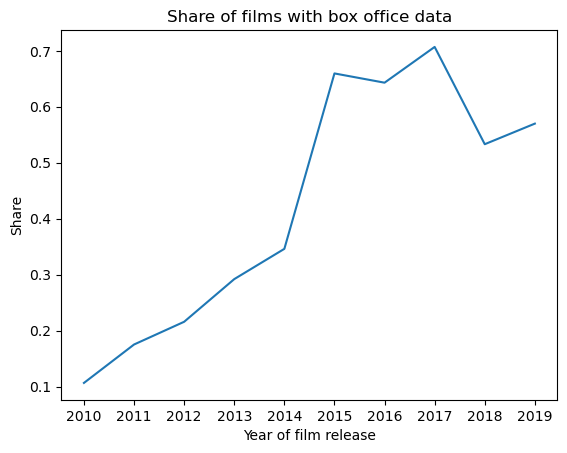

In [28]:
plt.title('Share of films with box office data')
plt.xlabel("Year of film release")
plt.ylabel("Share")
plt.plot(yearly_stats['box_office_percentage'])

It is noticeable that later years (2015-2019) have a much larger share of available data, with a peak in 2017 where the share reached approximately 70%.

<BarContainer object of 10 artists>

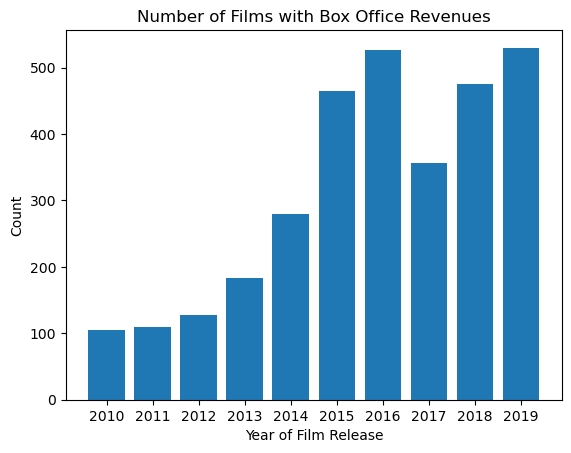

In [29]:
plt.figure()
plt.title('Number of Films with Box Office Revenues')
plt.xlabel("Year of Film Release")
plt.ylabel("Count")
plt.bar(yearly_stats.index, yearly_stats['movies_with_box_office'])

From this graph, you can see that over 9 years, the number of films with available box office data increased roughly 5 times.

Now, let's look at the overall share of films with known screening data across the entire dataframe.

In [30]:
total_movies = len(data)
movies_with_box_office = data['box_office'].notna().sum()
overall_box_office_percentage = movies_with_box_office / total_movies
print(f"Percentage of films with known box office data: {overall_box_office_percentage:.2%}")

Percentage of films with known box office data: 42.19%


Let's examine how the dynamics of box office revenues have changed over the years.

In [31]:
box_office_by_year = data.groupby('year')['box_office'].sum()

min_year = box_office_by_year.idxmin()
max_year = box_office_by_year.idxmax()

print(f"Year with the lowest revenues: {min_year}, Revenues: {box_office_by_year[min_year]}")
print(f"Year with the highest revenues: {max_year}, Revenues: {box_office_by_year[max_year]}")

Year with the lowest revenues: 2010, Revenues: 2428654.0
Year with the highest revenues: 2018, Revenues: 49668403134.32


In [32]:
display(box_office_by_year)

year
2010       2428654.00
2011      14102765.00
2012       6955423.00
2013      29799706.20
2014    7444951859.20
2015   39497365196.40
2016   47866299741.91
2017   48563707217.51
2018   49668403134.32
2019   48425708779.59
Name: box_office, dtype: float64

<BarContainer object of 10 artists>

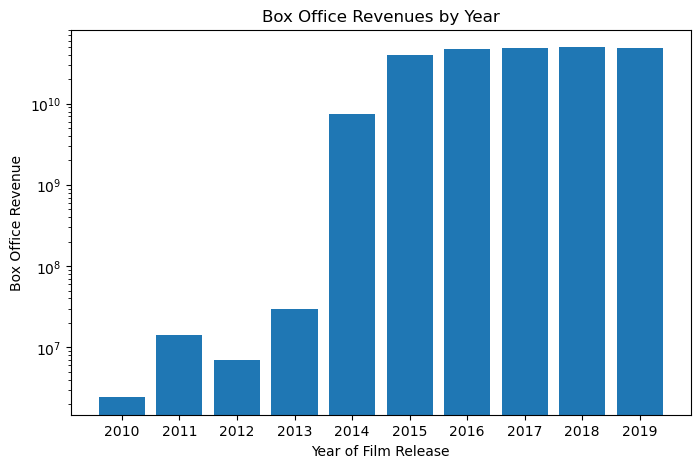

In [33]:
plt.figure(figsize=(8,5))
plt.title('Box Office Revenues by Year')
plt.xlabel("Year of Film Release")
plt.ylabel("Box Office Revenue")
plt.yscale('log')
plt.bar(box_office_by_year.index, box_office_by_year)

Record box office revenue was achieved in 2018. Such a sharp increase in revenue was most likely influenced by the inflation in 2014.

Let's look at the average and median values for each year.

In [34]:
pivot_table = data.pivot_table(
    index='year', 
    values='box_office', 
    aggfunc=['mean', 'median']
)

pivot_table.columns = ['avg_box_office', 'median_box_office']
display(pivot_table)

,avg_box_office,median_box_office
year,,
2010,23130.04,1700.00
2011,129383.17,3000.00
2012,54339.24,5660.00
2013,161954.92,3522.50
2014,26684415.27,18160.00
2015,84940570.31,4920933.00
2016,91000569.85,3846679.41
2017,136032793.33,9968340.00
2018,104565059.23,8891102.21


Does the audience age restriction (e.g., '6+', '12+', '16+', '18+', etc.) affect a film's box office revenue from 2015 to 2019? Which age restriction category gathered the most box office revenue? Does the pattern vary by year?

In [35]:
data['year'] = pd.to_datetime(data['year'], errors='coerce')
data['year'] = data['year'].dt.year
data = data.dropna(subset=['year'])
data['year'] = data['year'].astype(int) 

In [36]:
print("Number of films before filtering:", len(data))

filtered = data[(data['year'] >= 2015) & (data['year'] <= 2019)]

print("Number of films after filtering:", len(filtered))

age_revenue = filtered.groupby('age_restriction')['box_office'].sum().sort_values(ascending=False)

display(age_revenue)

Number of films before filtering: 7485
Number of films after filtering: 3849


age_restriction
«16+» - для детей старше 16 лет          76034733643.63
«12+» - для детей старше 12 лет          60619446628.33
«6+» - для детей старше 6 лет            55798610799.68
«18+» - запрещено для детей              40759615572.12
«0+» - для любой зрительской аудитории     809077425.97
Name: box_office, dtype: float64

<BarContainer object of 5 artists>

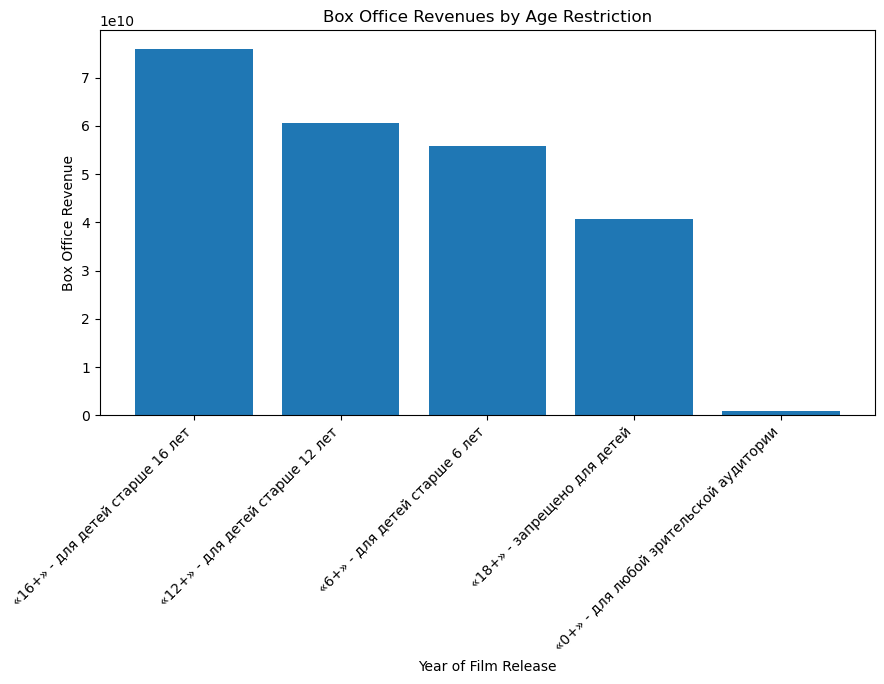

In [37]:
plt.figure(figsize=(10,5))
plt.title('Box Office Revenues by Age Restriction')
plt.xlabel("Year of Film Release")
plt.ylabel("Box Office Revenue")
plt.xticks(rotation=45, ha="right")
plt.bar(age_revenue.index, age_revenue)

As can be seen, films with the '16+' category have the highest revenue. This is most likely because such films are ideally suited for both teenage audiences and adults.

## Study of Films with State Support

How much money is allocated for film support?

In [38]:
data['total_support'] = data['refundable_support'].fillna(0) + data['nonrefundable_support'].fillna(0)
total_support_sum = data['total_support'].sum()
print(f"Total film support amount: {total_support_sum} rubles")

Total film support amount: 20200688312.0 rubles


Average rating of films with support

In [39]:
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')
avg_rating_supported = data[data['total_support'] > 0]['ratings'].mean()
avg_rating_no_support = data[data['total_support'] == 0]['ratings'].mean()

print(f"Average rating of films with support: {avg_rating_supported:.2f}")
print(f"Average rating of films without support: {avg_rating_no_support:.2f}")

Average rating of films with support: 5.97
Average rating of films without support: 6.48


How well do supported films recoup their costs?

In [40]:
data['total_support'] = data['total_support'].replace(0, pd.NA)
data['profitability'] = data['box_office'] / data['total_support']
profitability_stats = data[['total_support', 'box_office', 'profitability']].dropna().describe()
display(profitability_stats)

,box_office
count,318.00
mean,132432420.05
std,334837856.99
min,1550.00
25%,1236675.50
50%,15720067.71
75%,106373008.27
max,3073568690.79


The average box office revenue is 132 million rubles, while the median revenue is 15 million.

Which studios are the most successful?

In [41]:
studios = data.groupby('film_studio')['box_office'].sum().sort_values(ascending=False)
top_studios = studios.head(10)

<BarContainer object of 10 artists>

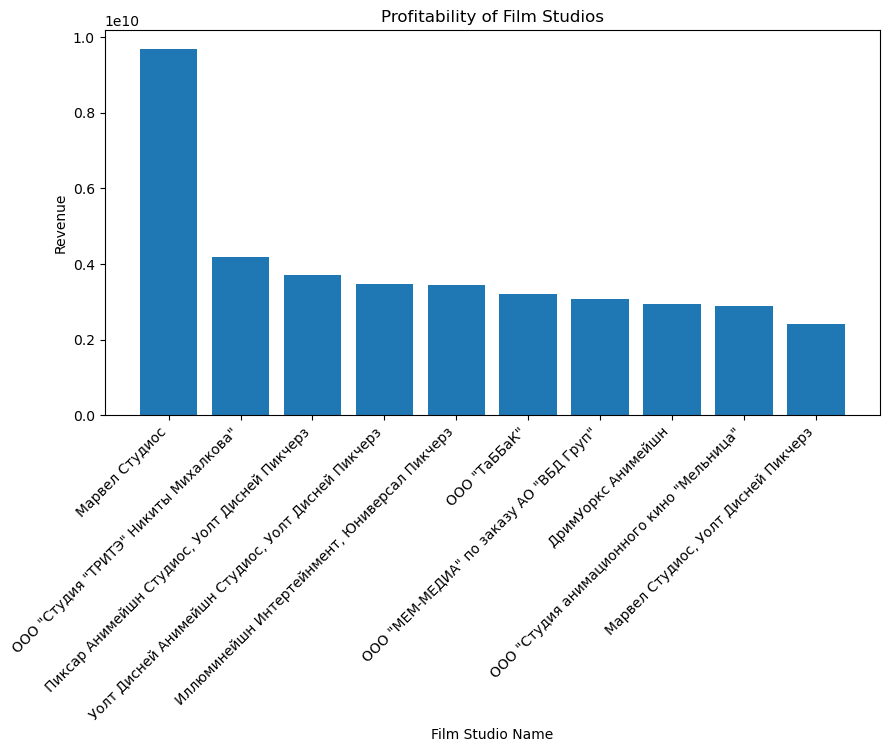

In [42]:
plt.figure(figsize=(10,5))
plt.title('Profitability of Film Studios')
plt.xlabel("Film Studio Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.bar(top_studios.index, top_studios)

The top 10 most profitable film studios are shown above, with Marvel leading thanks to their huge box office revenues from the "Avengers" film series.

In [43]:
producers = data.groupby('producer')['box_office'].sum().sort_values(ascending=False)
top_producer = producers.head(10)

<BarContainer object of 10 artists>

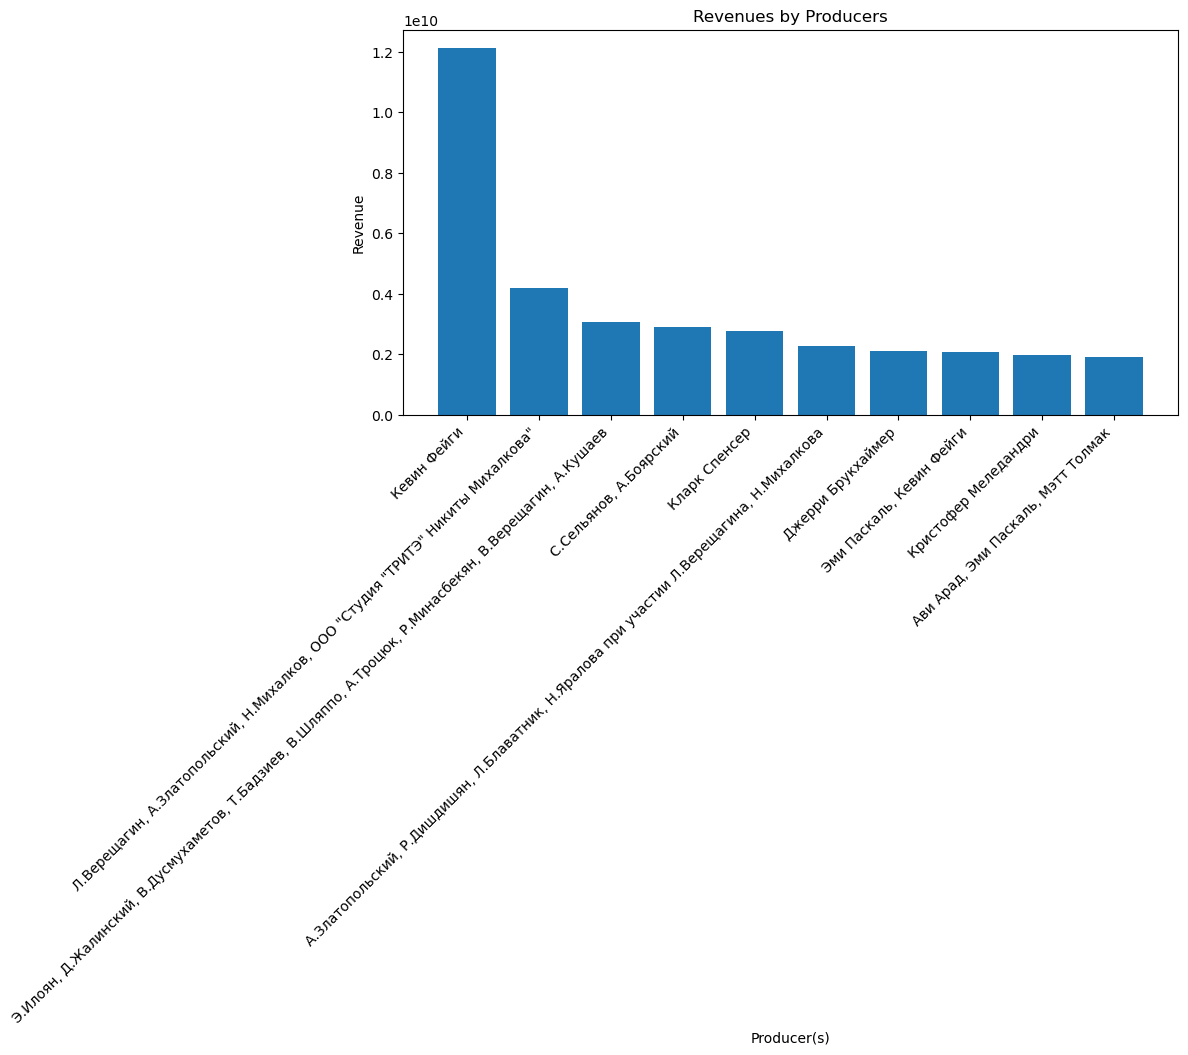

In [44]:
plt.figure(figsize=(10,5))
plt.title('Revenues by Producers')
plt.xlabel("Producer(s)")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.bar(top_producer.index, top_producer)

The most profitable producer turned out to be Kevin Feige, who produced the Avengers.

In [45]:
directors = data.groupby('director')['box_office'].sum().sort_values(ascending=False)
top_directors = directors.head(10)

<BarContainer object of 10 artists>

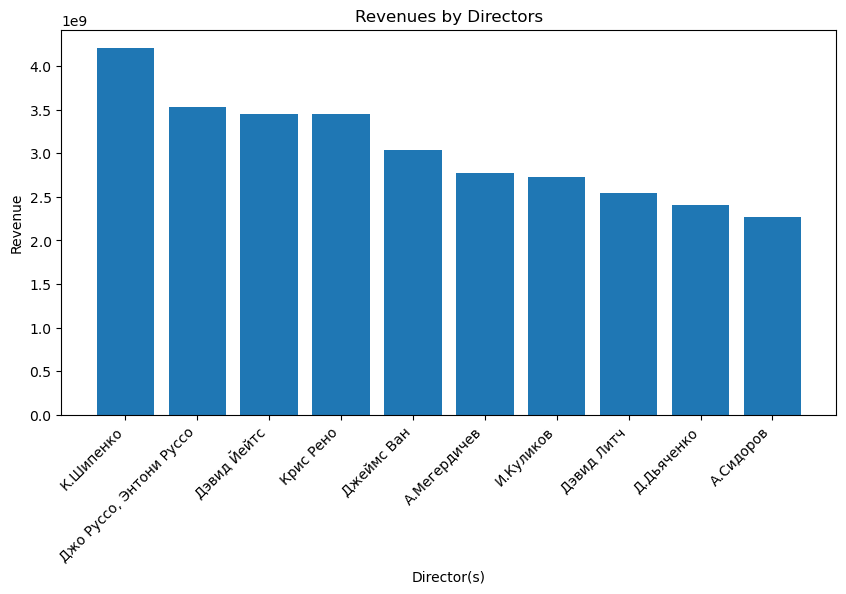

In [46]:
plt.figure(figsize=(10,5))
plt.title('Revenues by Directors')
plt.xlabel("Director(s)")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.bar(top_directors.index, top_directors)

The most profitable director turned out to be Shipenko, followed by the Russo brothers, who created the Avengers.

## Overall Conclusion

Several conclusions can be drawn from the data analysis. In recent years, screening data has been recorded more actively than before. Box office revenue has also increased, but it is difficult to say which had a greater impact: increased interest in films or the weakening of the ruble. Age restrictions definitely affect box office revenue, with films rated "16+" being the most profitable. This is most likely because such films exclude horror and excessive violence, and instead address serious themes of love and friendship, which generate great interest among most consumers.

Overall, in recent times, 20 billion rubles have been spent on film support. The average rating of films without support is slightly better than that of films with support, possibly due to a stronger motivation and financial responsibility on the part of the director. The vast majority of films have low revenue, while the average box office revenue is significantly boosted by blockbusters. For example, the most profitable producers, directors, and studios are generally associated with the blockbuster series "Avengers".